In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- clean_dataset
- ecommerce_churn


In [3]:
for table in tables:
    #    print(f"\n Table: {table}")
       query = text(f"SELECT COUNT(*) FROM {table}")
       df = pd.read_sql_query(query, engine)
       print(f"{table}", df.iloc[0,0])
       display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine))

clean_dataset 5630


,customerid,churn,tenure_no_of_month_stay,login_device,citytier,warehouse_to_home,payment_mode,gender,hour_spend_on_app,number_of_device_registered,order_cat,satisfactionscore,marital_status,number_of_address,complain,order_amount_hike_from_last_year,couponused,ordercount,days_since_last_order,cashbackamount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,9.0,Mobile Phone,1,8.0,UPI,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,9.0,Mobile Phone,1,30.0,Debit Card,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Mobile Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Mobile Phone,1,12.0,Credit Card,Male,3.0,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,130


ecommerce_churn 5630


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [4]:
df = pd.read_sql_query(text("""select * from clean_dataset"""),engine)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customerid,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
churn,5630.0,0.168384,0.374240,0.0,0.00,0.0,0.00,1.0
tenure_no_of_month_stay,5630.0,10.134103,8.357951,0.0,3.00,9.0,15.00,61.0
citytier,5630.0,1.654707,0.915389,1.0,1.00,1.0,3.00,3.0
warehouse_to_home,5630.0,15.566785,8.345961,5.0,9.00,14.0,20.00,127.0
hour_spend_on_app,5630.0,2.934636,0.705528,0.0,2.00,3.0,3.00,5.0
number_of_device_registered,5630.0,3.688988,1.023999,1.0,3.00,4.0,4.00,6.0
satisfactionscore,5630.0,3.066785,1.380194,1.0,2.00,3.0,4.00,5.0
number_of_address,5630.0,4.214032,2.583586,1.0,2.00,3.0,6.00,22.0
complain,5630.0,0.284902,0.451408,0.0,0.00,0.0,1.00,1.0


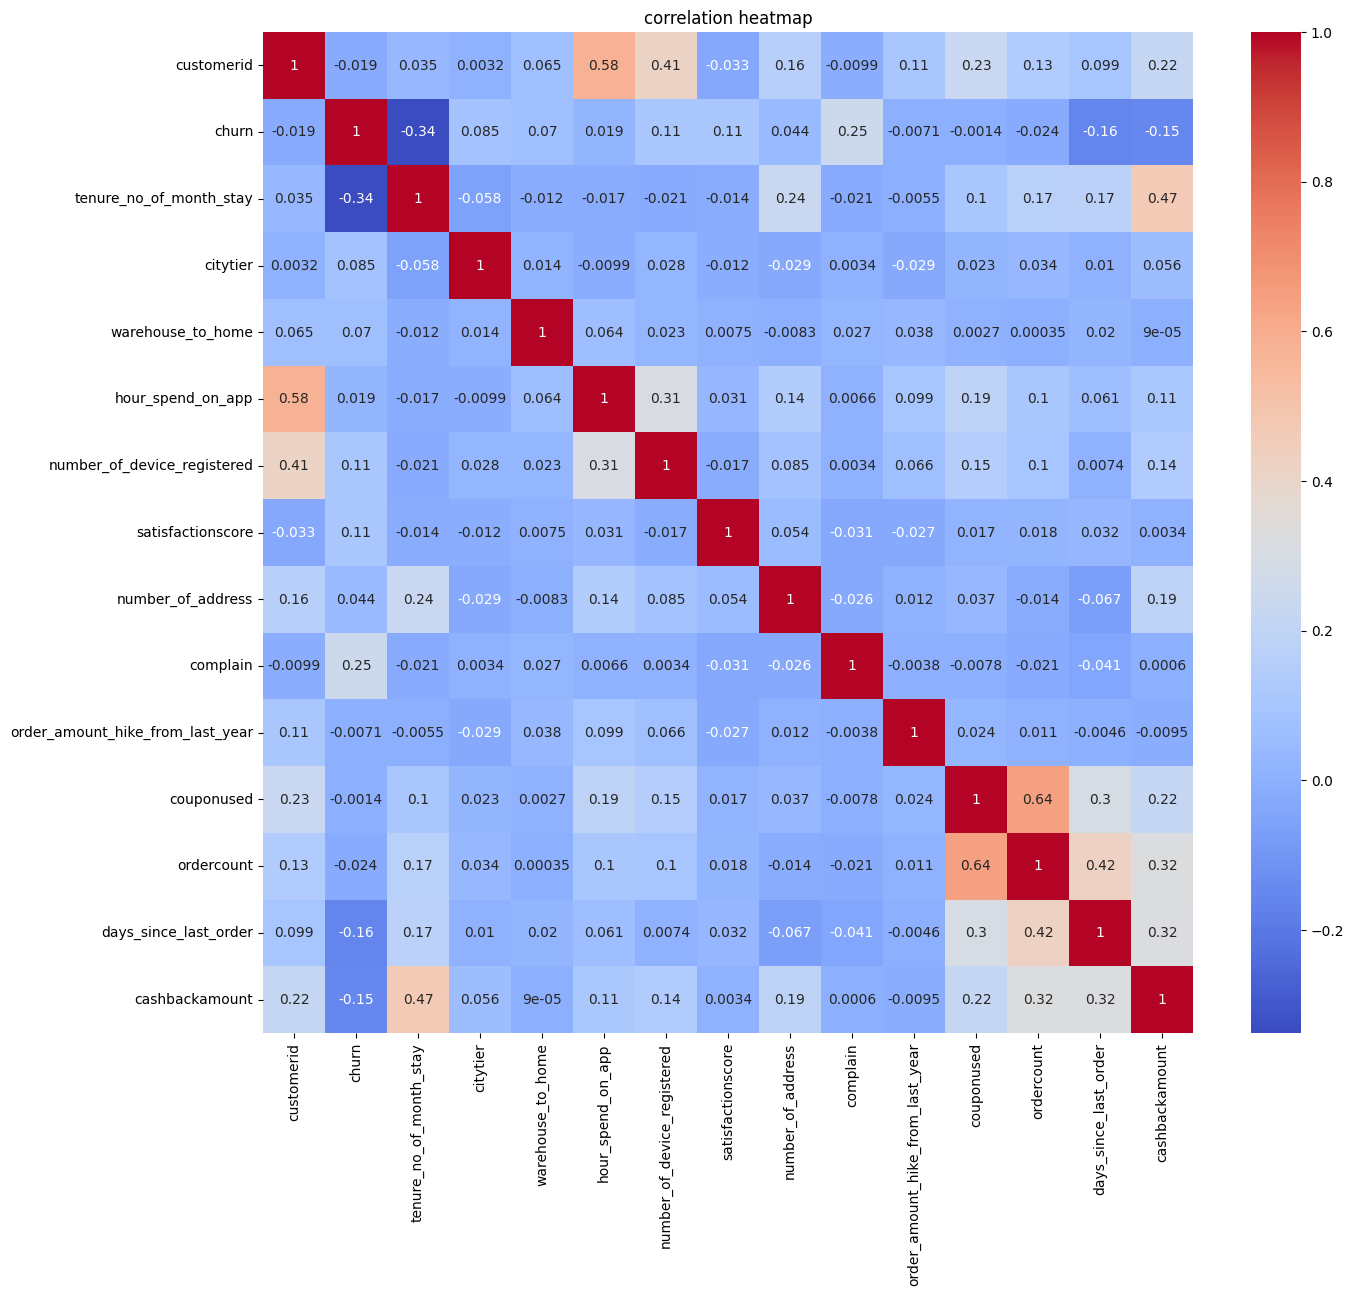

In [6]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(15,13))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

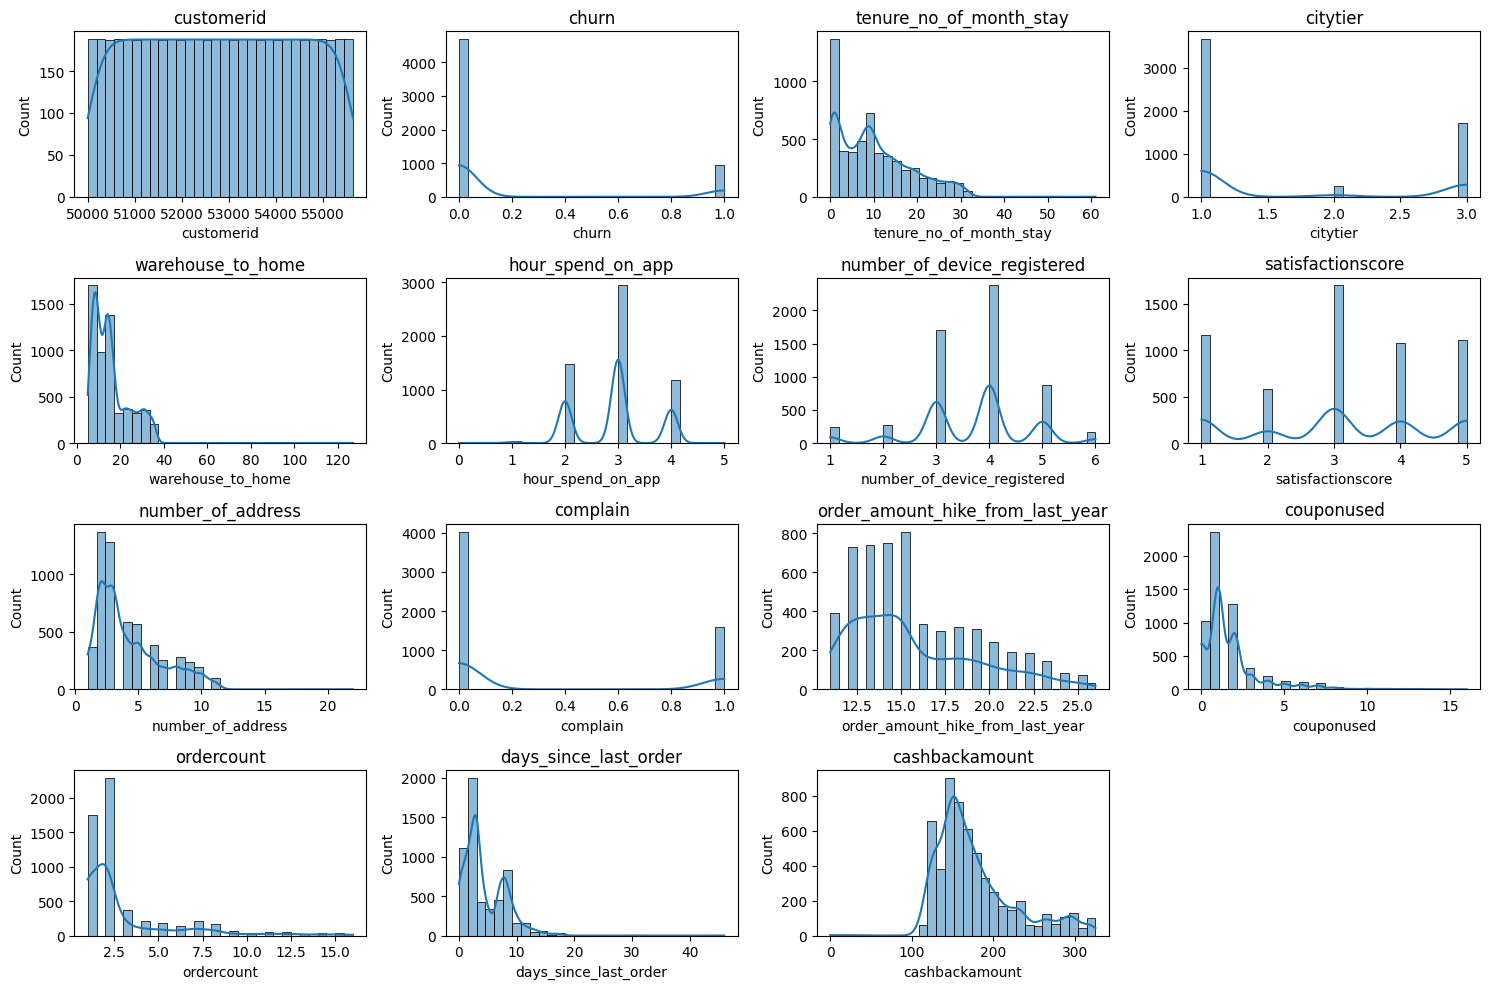

In [7]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

**as werehouse to home hasmost value accure between 0 to 50 but very few accure upper 100 ao i remove that outliers**

In [8]:
# remove outliers from warehouse_to_home 
Q1 = df["warehouse_to_home"].quantile(0.25)
Q3 = df["warehouse_to_home"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

df = df[
    (df["warehouse_to_home"] >= lower_bound) &
    (df["warehouse_to_home"] <= upper_bound)
].copy()

print(f"Dataset shape after removing outliers: {df.shape}")

Lower Bound: -7.50
Upper Bound: 36.50
Dataset shape after removing outliers: (5628, 20)


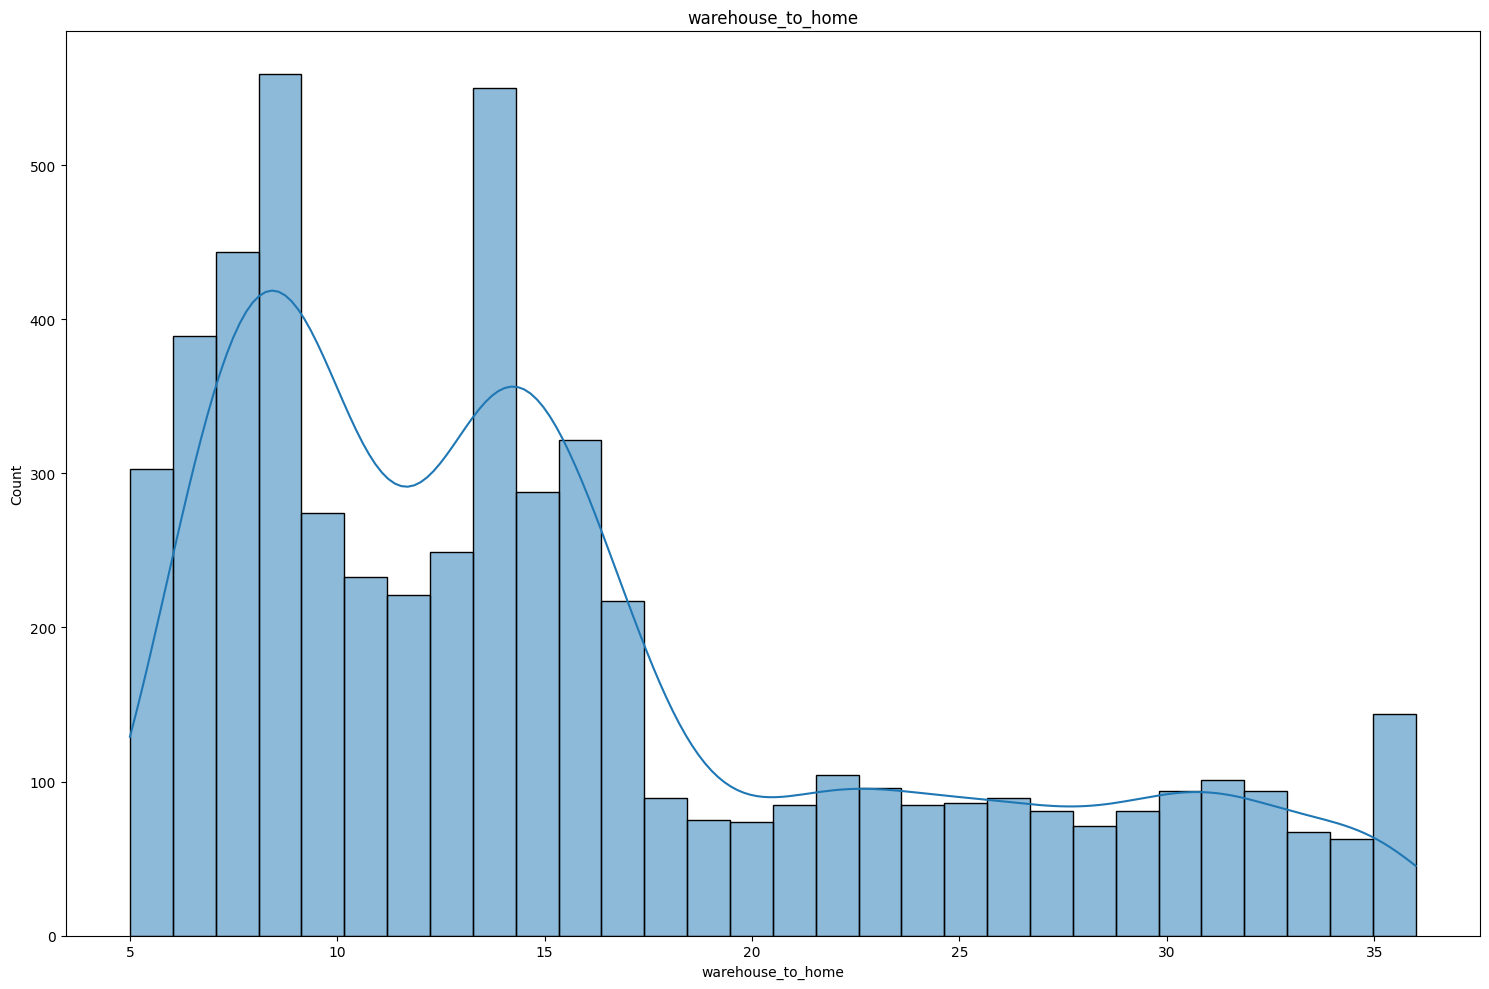

In [9]:
numerical_cols =['warehouse_to_home']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

**save dataset to mysql after remove outliers**

In [11]:
df.to_sql(name="clean_dataset",
          con=engine , 
          if_exists="replace" , 
          index=False,
          chunksize=500)
print("clean dataset save in mysql after remove outliers")

clean dataset save in mysql after remove outliers


* sql analysis

1 . What is the overall customer churn rate?

,customer_segment,total_customer,churn_rate
0,churn,948,16.84
1,retanied,4680,83.16


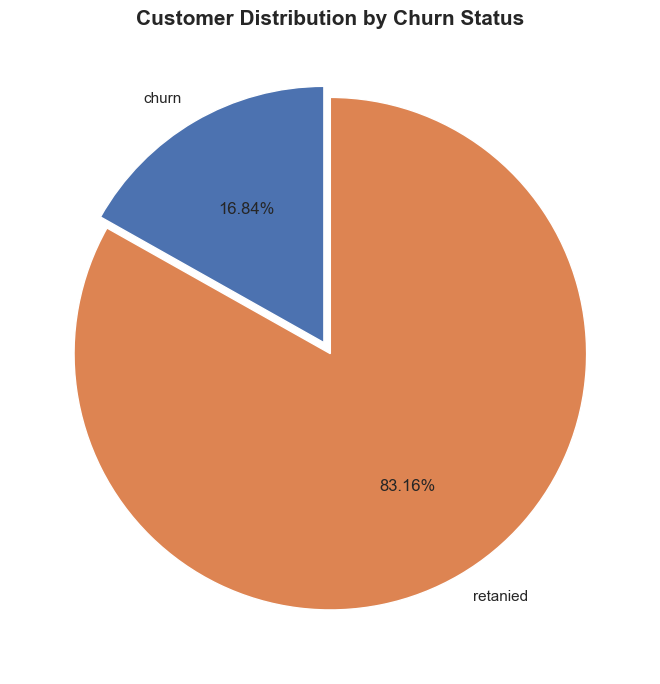

In [64]:
churn_rate = pd.read_sql_query(text("""select case when churn = 1 then "churn" else "retanied" end as customer_segment , count(*) as total_customer  , 
round(100.0 * count(*) / sum(count(*))over() , 2) as churn_rate from clean_dataset group by churn """),engine)
display(churn_rate)

plt.figure(figsize=(7, 7))

plt.pie(
    churn_rate['total_customer'],   # or churn_rate['churn_rate']
    labels=churn_rate['customer_segment'],
    autopct='%1.2f%%',
    startangle=90,
    explode=(0.05, 0),              # Highlight the churn slice
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1
    }
)

plt.title(
    'Customer Distribution by Churn Status',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

2 . How does churn rate vary by CityTier?

,citytier,total_customer,total_churn,churn_rate
0,1,3666,532,14.51
1,2,242,48,19.83
2,3,1720,368,21.40


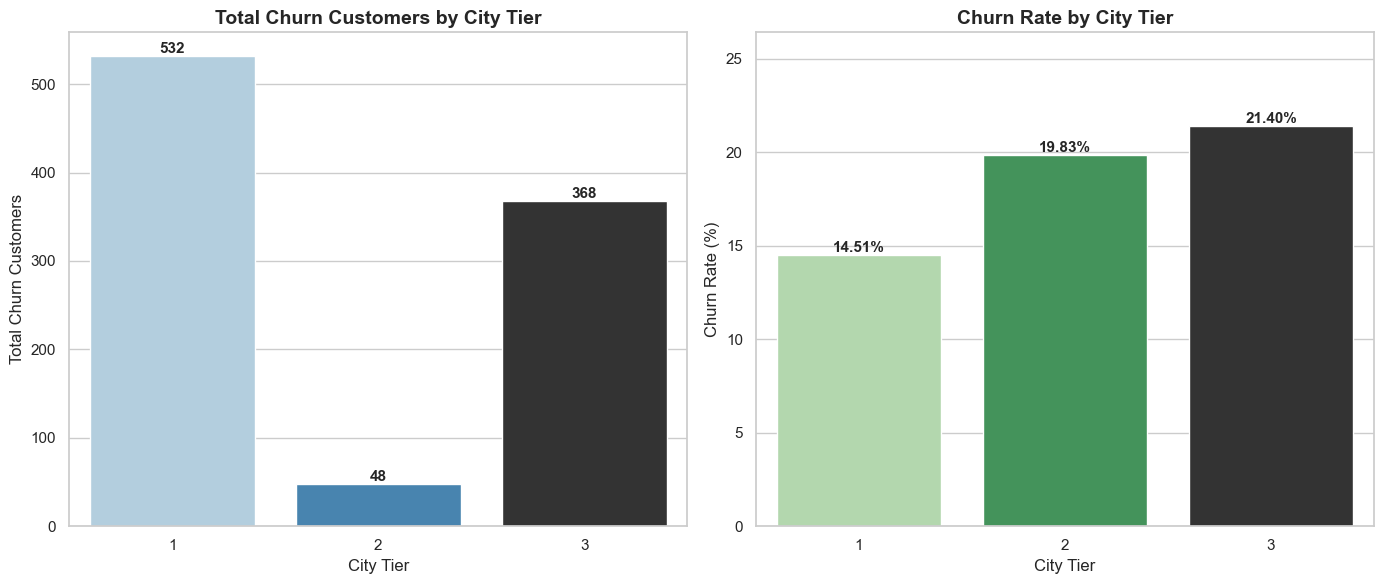

In [63]:
city_tier_rate = pd.read_sql_query(text("""select citytier , count(*) as total_customer  , 
count(case when churn = 1 then 1 end) as total_churn , round(100.0 * count(case when churn = 1 then 1 end) 
/ count(*),2) as churn_rate 
from clean_dataset group by citytier  order by citytier"""),engine)
display(city_tier_rate)

# Style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------
# Bar Chart 1 : Total Churn Customers
# --------------------------
ax1 = sns.barplot(
    data=city_tier_rate,
    x='citytier',
    y='total_churn',
    hue='citytier',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

# Add data labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

axes[0].set_title(
    'Total Churn Customers by City Tier',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('City Tier', fontsize=12)
axes[0].set_ylabel('Total Churn Customers', fontsize=12)

# --------------------------
# Bar Chart 2 : Churn Rate
# --------------------------
ax2 = sns.barplot(
    data=city_tier_rate,
    x='citytier',
    y='churn_rate',
    hue='citytier',
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)

# Add percentage labels
for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt='%.2f%%',
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_title(
    'Churn Rate by City Tier',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('City Tier', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)

# Set y-limit for better spacing
axes[1].set_ylim(0, city_tier_rate['churn_rate'].max() + 5)

plt.tight_layout()
plt.show()

3 . How does churn rate differ by PreferredPaymentMode? — checks if payment friction (e.g., COD) drives attrition.

,payment_mode,total_customer,total_churn,churn_rate
0,Debit Card,2312,356.0,15.40
1,UPI,414,72.0,17.39
2,Credit Card,1774,252.0,14.21
3,Cash on Delivery,514,128.0,24.90
4,E wallet,614,140.0,22.80


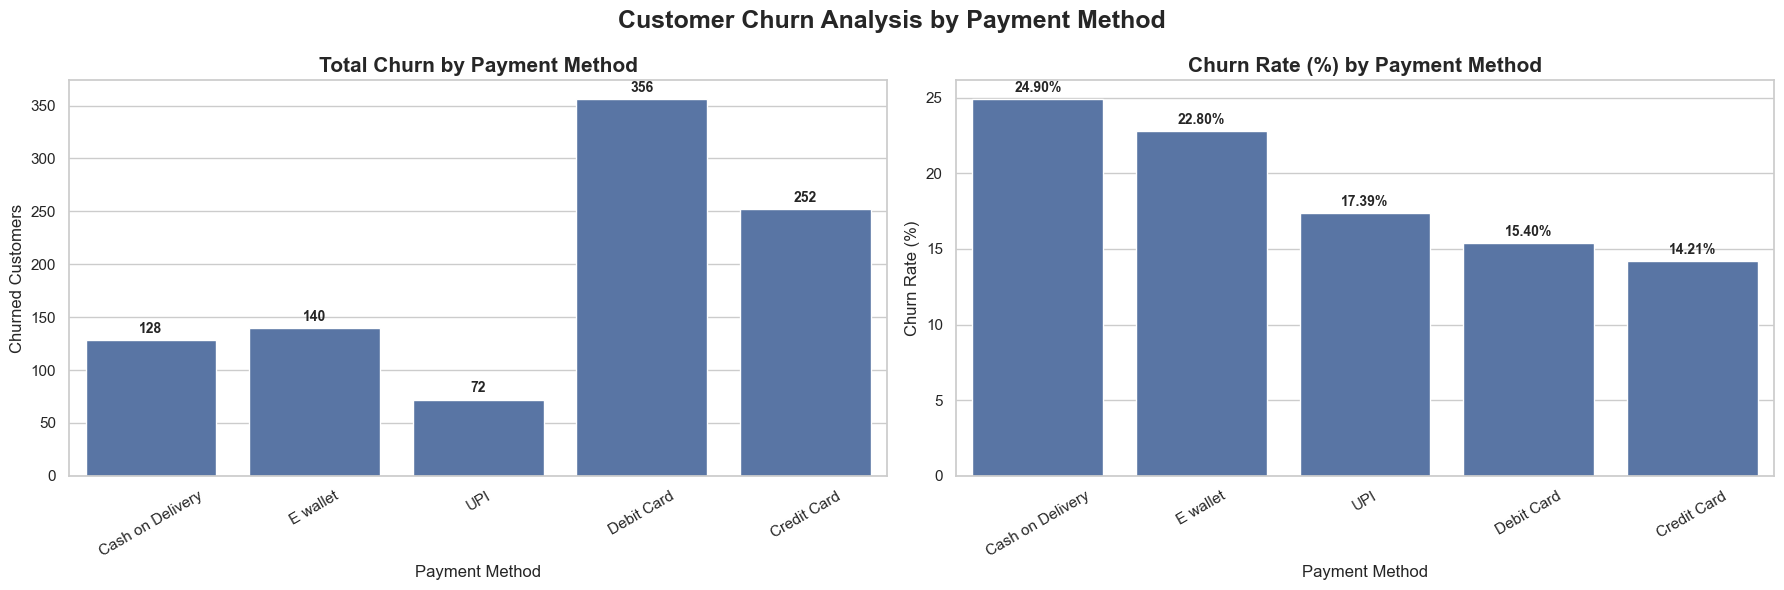

In [57]:
payment_method = pd.read_sql_query(text("""select payment_mode ,count(*) as total_customer , sum(churn) as total_churn , round(100.0 * count(case when churn = 1 then 1 end) 
/ count(*),2) as churn_rate from clean_dataset group by payment_mode  """),engine)
display(payment_method)

# Sort by churn rate (highest to lowest)
payment_method_sorted = payment_method.sort_values(
    by='churn_rate',
    ascending=False
)

# Set style
sns.set_theme(style='whitegrid')

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# ======================================
# Total Churn by Payment Method
# ======================================
sns.barplot(
    data=payment_method_sorted,
    x='payment_mode',
    y='total_churn',
    ax=ax[0]
)

# Data labels
for container in ax[0].containers:
    ax[0].bar_label(container,
                    fmt='%d',
                    padding=3,
                    fontsize=10,
                    fontweight='bold')

ax[0].set_title('Total Churn by Payment Method',
                fontsize=15,
                fontweight='bold')

ax[0].set_xlabel('Payment Method', fontsize=12)
ax[0].set_ylabel('Churned Customers', fontsize=12)
ax[0].tick_params(axis='x', rotation=30)

# ======================================
# Churn Rate by Payment Method
# ======================================
sns.barplot(
    data=payment_method_sorted,
    x='payment_mode',
    y='churn_rate',
    ax=ax[1]
)

# Percentage labels
for container in ax[1].containers:
    ax[1].bar_label(container,
                    fmt='%.2f%%',
                    padding=3,
                    fontsize=10,
                    fontweight='bold')

ax[1].set_title('Churn Rate (%) by Payment Method',
                fontsize=15,
                fontweight='bold')

ax[1].set_xlabel('Payment Method', fontsize=12)
ax[1].set_ylabel('Churn Rate (%)', fontsize=12)
ax[1].tick_params(axis='x', rotation=30)

# Overall title
plt.suptitle('Customer Churn Analysis by Payment Method',
             fontsize=18,
             fontweight='bold')

plt.tight_layout()
plt.show()

4 . What's the average Tenure for churned vs. retained customers? — shows whether churn is an early-lifecycle problem.

,customer_segment,avg_tenure,total_customer
0,churn,3.86,948
1,retanied,11.40,4680


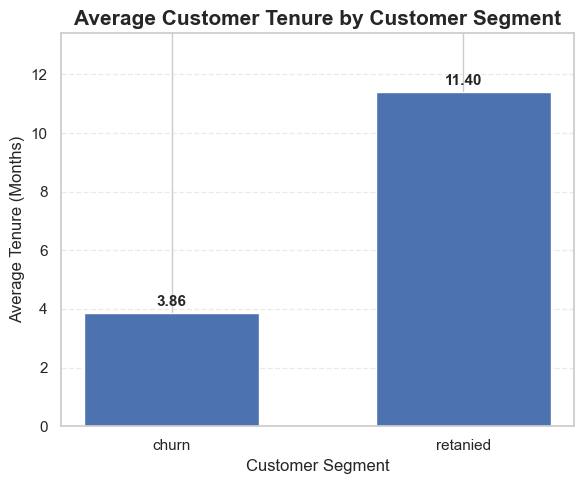

In [59]:
avg_tenure = pd.read_sql_query(text("""select case when churn = 1 then "churn" else "retanied" end as customer_segment , round(avg(tenure_no_of_month_stay),2) as avg_tenure , count(*) as total_customer from clean_dataset group by churn"""),engine)
display(avg_tenure)


# Create figure
plt.figure(figsize=(6,5))

# Create bar chart
bars = plt.bar(
    avg_tenure['customer_segment'],
    avg_tenure['avg_tenure'],
    width=0.6
)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Formatting
plt.title('Average Customer Tenure by Customer Segment',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Average Tenure (Months)', fontsize=12)

plt.ylim(0, avg_tenure['avg_tenure'].max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

5 . How does average SatisfactionScore compare between churned and retained customers? — tests if dissatisfaction is a leading churn signal.

,customer_segment,avg_satisfaction_score
0,churn,3.39
1,retanied,3.00


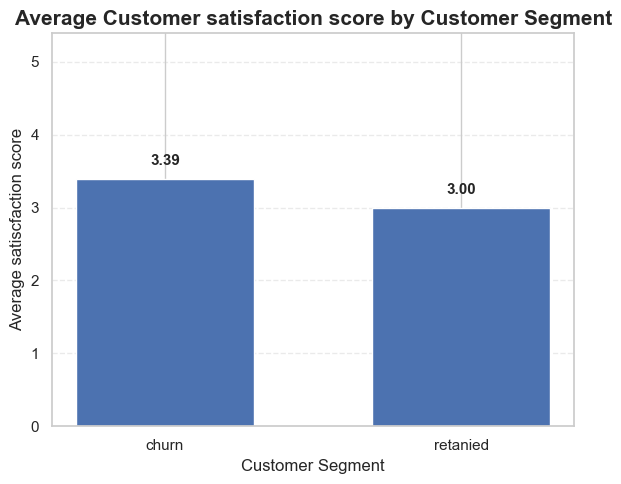

In [60]:
satisfaction = pd.read_sql_query(text("""select case when churn = 1 then "churn" else "retanied" end as customer_segment , round(avg(satisfactionscore),2) avg_satisfaction_score from clean_dataset group by churn """),engine)
display(satisfaction)


# Create figure
plt.figure(figsize=(6,5))

# Create bar chart
bars = plt.bar(
    satisfaction['customer_segment'],
    satisfaction['avg_satisfaction_score'],
    width=0.6
)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Formatting
plt.title('Average Customer satisfaction score by Customer Segment',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Average satiscfaction score', fontsize=12)

plt.ylim(0, satisfaction['avg_satisfaction_score'].max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

6 . What is the churn rate by MaritalStatus? — checks if life-stage segments behave differently.

,marital_status,total_churn,total_customer,churn_rate
0,Single,480.0,1796,26.73
1,Divorced,124.0,848,14.62
2,Married,344.0,2984,11.53


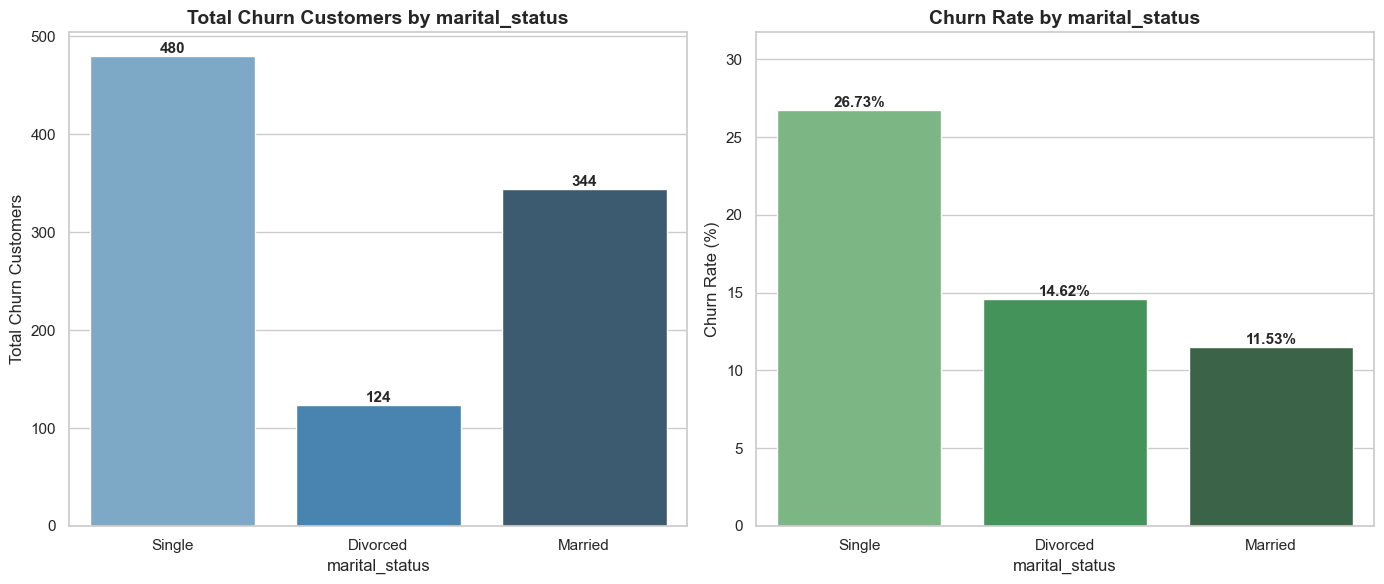

In [65]:
marital_status = pd.read_sql_query(text("""select marital_status , sum(churn) as total_churn , count(*) as total_customer  , round(100.0 * sum(churn) / count(*),2) as churn_rate  from clean_dataset group by marital_status """),engine)
display(marital_status)

# Style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------
# Bar Chart 1 : Total Churn Customers
# --------------------------
ax1 = sns.barplot(
    data=marital_status,
    x='marital_status',
    y='total_churn',
    hue='marital_status',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

# Add data labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

axes[0].set_title(
    'Total Churn Customers by marital_status',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('marital_status', fontsize=12)
axes[0].set_ylabel('Total Churn Customers', fontsize=12)

# --------------------------
# Bar Chart 2 : Churn Rate
# --------------------------
ax2 = sns.barplot(
    data=marital_status,
    x='marital_status',
    y='churn_rate',
    hue='marital_status',
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)

# Add percentage labels
for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt='%.2f%%',
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_title(
    'Churn Rate by marital_status',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('marital_status', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)

# Set y-limit for better spacing
axes[1].set_ylim(0, marital_status['churn_rate'].max() + 5)

plt.tight_layout()
plt.show()

7 . Does raising a complaint (Complain=1) increase churn probability, and by how much? — quantifies the ROI of better complaint resolution.

,complain,total_customer,total_churn,churn_rate
0,yes,1604,508.0,31.67
1,no,4024,440.0,10.93


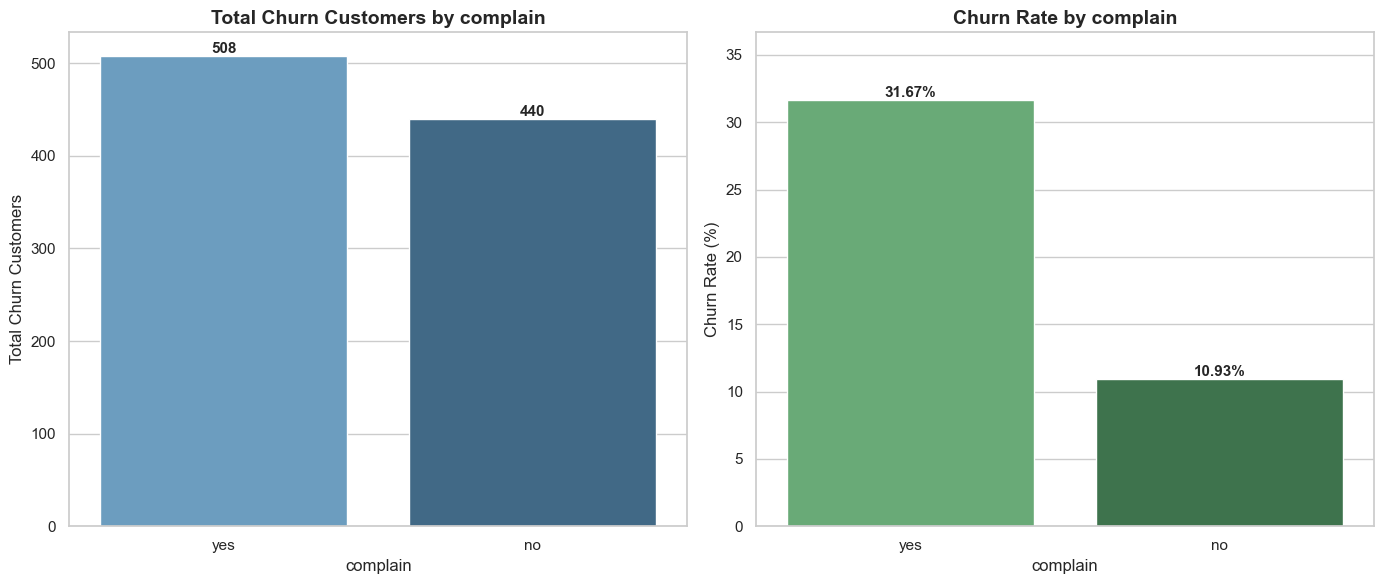

In [66]:
complain_churn = pd.read_sql_query(text("""select case when complain = 1 then "yes"
else "no" end as complain , count(*) as total_customer  , sum(churn) as total_churn , round(100.0 * sum(churn) / count(*),2) as churn_rate from clean_dataset group by complain """),engine)
display(complain_churn)

# Style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------
# Bar Chart 1 : Total Churn Customers
# --------------------------
ax1 = sns.barplot(
    data=complain_churn,
    x='complain',
    y='total_churn',
    hue='complain',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

# Add data labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

axes[0].set_title(
    'Total Churn Customers by complain',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('complain', fontsize=12)
axes[0].set_ylabel('Total Churn Customers', fontsize=12)

# --------------------------
# Bar Chart 2 : Churn Rate
# --------------------------
ax2 = sns.barplot(
    data=complain_churn,
    x='complain',
    y='churn_rate',
    hue='complain',
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)

# Add percentage labels
for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt='%.2f%%',
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_title(
    'Churn Rate by complain',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('complain', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)

# Set y-limit for better spacing
axes[1].set_ylim(0, complain_churn['churn_rate'].max() + 5)

plt.tight_layout()
plt.show()

8 . Which PreferedOrderCat has the highest churn rate? — tells the category/merchandising team where retention risk concentrates.

,order_cat,total_customer,total_churn,churn_rate
0,Mobile Phone,2078,570.0,27.43
1,Fashion,826,128.0,15.50
2,Laptop & Accessory,2050,210.0,10.24
3,Others,264,20.0,7.58
4,Grocery,410,20.0,4.88


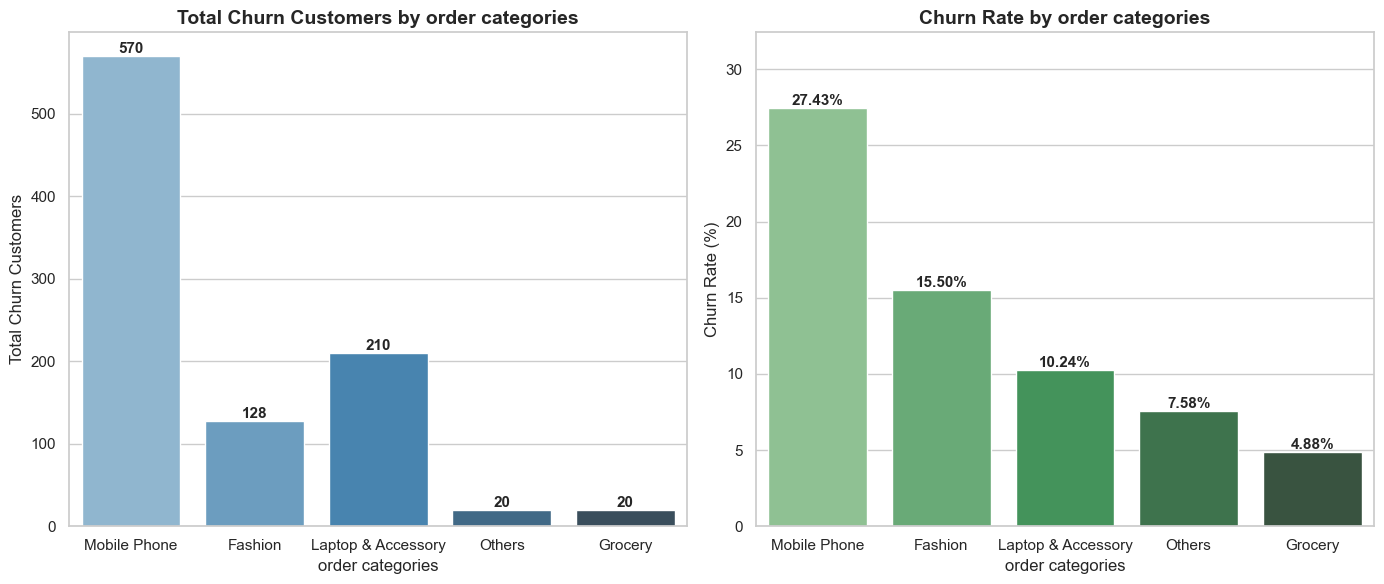

In [67]:
category_churn = pd.read_sql_query(text("""select order_cat , count(*) as total_customer  , sum(case when churn = 1 then 1 end) as total_churn , round(100.0 * sum(case when churn = 1 then 1 end) / count(*),2) as churn_rate from clean_dataset group by order_cat order by churn_rate desc """),engine)
display(category_churn)

# Style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------
# Bar Chart 1 : Total Churn Customers
# --------------------------
ax1 = sns.barplot(
    data=category_churn,
    x='order_cat',
    y='total_churn',
    hue='order_cat',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

# Add data labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

axes[0].set_title(
    'Total Churn Customers by order categories',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('order categories', fontsize=12)
axes[0].set_ylabel('Total Churn Customers', fontsize=12)

# --------------------------
# Bar Chart 2 : Churn Rate
# --------------------------
ax2 = sns.barplot(
    data=category_churn,
    x='order_cat',
    y='churn_rate',
    hue='order_cat',
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)

# Add percentage labels
for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt='%.2f%%',
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_title(
    'Churn Rate by order categories',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('order categories', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)

# Set y-limit for better spacing
axes[1].set_ylim(0, category_churn['churn_rate'].max() + 5)

plt.tight_layout()
plt.show()

9 . Is there a DaySinceLastOrder threshold beyond which churn risk spikes? — defines a trigger point for win-back campaigns.

,last_order_bucket,total_customer,total_churn,churn_rate
0,16+ days,43,1.0,2.33
1,11-15 days,265,18.0,6.79
2,8-10 days,994,104.0,10.46
3,4-7 days,1219,167.0,13.70
4,0-3 days,3107,658.0,21.18


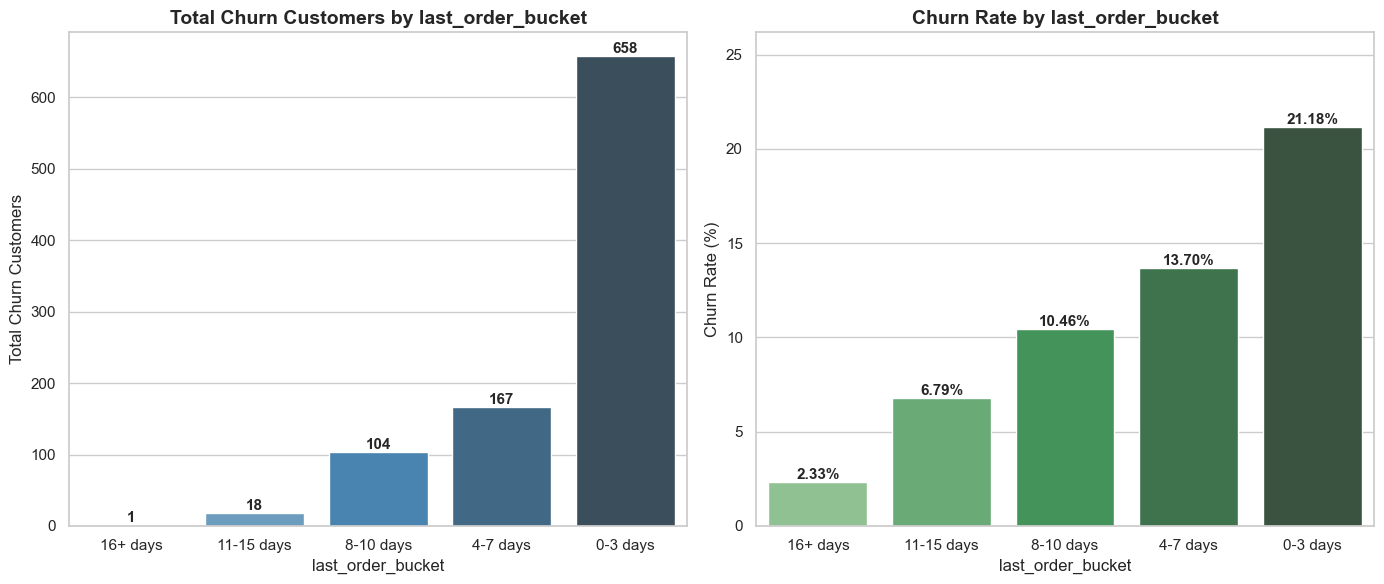

In [68]:
last_order_churn = pd.read_sql_query(text("""select case when days_since_last_order between 0 and 3 then "0-3 days"
when days_since_last_order between 4 and 7 then "4-7 days" 
when days_since_last_order between 8 and 10 then "8-10 days"
 when days_since_last_order between 11 and 15 then "11-15 days" 
 else "16+ days" end as last_order_bucket  ,  count(*) as total_customer  , sum(churn) as total_churn , 
round(100.0 * sum(churn) / count(*),2) as churn_rate from clean_dataset group by last_order_bucket 
order by churn_rate """),engine)
display(last_order_churn)

# Style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------
# Bar Chart 1 : Total Churn Customers
# --------------------------
ax1 = sns.barplot(
    data=last_order_churn,
    x='last_order_bucket',
    y='total_churn',
    hue='last_order_bucket',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

# Add data labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

axes[0].set_title(
    'Total Churn Customers by last_order_bucket',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('last_order_bucket', fontsize=12)
axes[0].set_ylabel('Total Churn Customers', fontsize=12)

# --------------------------
# Bar Chart 2 : Churn Rate
# --------------------------
ax2 = sns.barplot(
    data=last_order_churn,
    x='last_order_bucket',
    y='churn_rate',
    hue='last_order_bucket',
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)

# Add percentage labels
for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt='%.2f%%',
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_title(
    'Churn Rate by last_order_bucket',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('last_order_bucket', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)

# Set y-limit for better spacing
axes[1].set_ylim(0, last_order_churn['churn_rate'].max() + 5)

plt.tight_layout()
plt.show()

10 . How does CouponUsed differ between churned and active customers? — evaluates whether coupons actually retain customers or just get used before leaving.

In [41]:
coupon_churn = pd.read_sql_query(text("""SELECT
   case when churn = 1 then "churn" else "retanied" end as customer_segment,
    COUNT(*) AS total_customers,
    ROUND(AVG(couponused),2) AS avg_coupon_used,
    MIN(couponused) AS min_coupon_used,
    MAX(couponused) AS max_coupon_used
FROM clean_dataset
GROUP BY churn;"""),engine)
display(coupon_churn)

,customer_segment,total_customers,avg_coupon_used,min_coupon_used,max_coupon_used
0,churn,948,1.71,0.0,16.0
1,retanied,4680,1.72,0.0,16.0


11 . Does churn rate change with NumberOfDeviceRegistered? — tests if multi-device usage signals stronger platform stickiness.

,number_of_device_registered,total_churn,total_customer,churn_rate
0,1,22.0,235,9.36
1,2,26.0,276,9.42
2,3,254.0,1698,14.96
3,4,392.0,2376,16.50
4,5,198.0,881,22.47
5,6,56.0,162,34.57


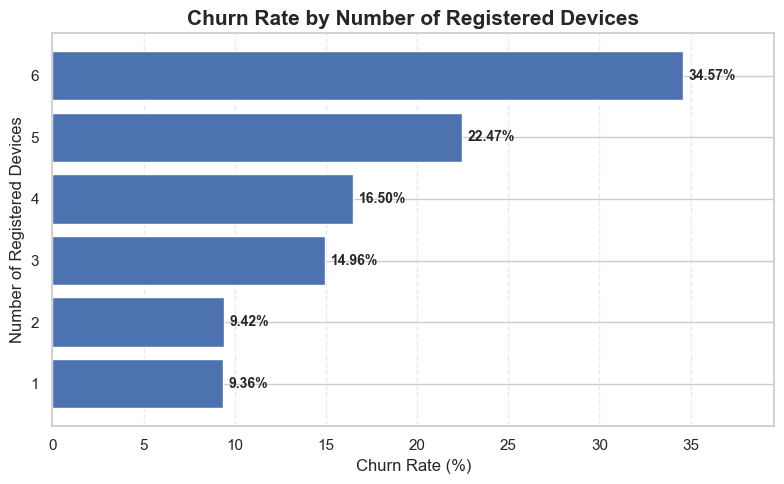

In [71]:
no_of_device = pd.read_sql_query(text("""select number_of_device_registered , sum(churn) as total_churn , count(*) as total_customer  , round(100.0 * sum(churn) / count(*),2) as churn_rate from clean_dataset group by number_of_device_registered order by number_of_device_registered """),engine)
display(no_of_device)

# Sort data (optional, if not already sorted)
no_of_device = no_of_device.sort_values('number_of_device_registered')

# Create figure
plt.figure(figsize=(8, 5))

# Horizontal bars
bars = plt.barh(
    no_of_device['number_of_device_registered'].astype(str),
    no_of_device['churn_rate']
)

# Add churn rate labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,                           # Position slightly after the bar
        bar.get_y() + bar.get_height() / 2,    # Center vertically
        f'{width:.2f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Formatting
plt.title('Churn Rate by Number of Registered Devices',
          fontsize=15, fontweight='bold')
plt.xlabel('Churn Rate (%)', fontsize=12)
plt.ylabel('Number of Registered Devices', fontsize=12)

plt.xlim(0, no_of_device['churn_rate'].max() + 5)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

12 . How does average CashbackAmount compare between churned and retained customers? — evaluates cashback as a loyalty lever.

,customer_segment,avg_cashback,total_customer
0,churn,160.37,948
1,retanied,180.65,4680


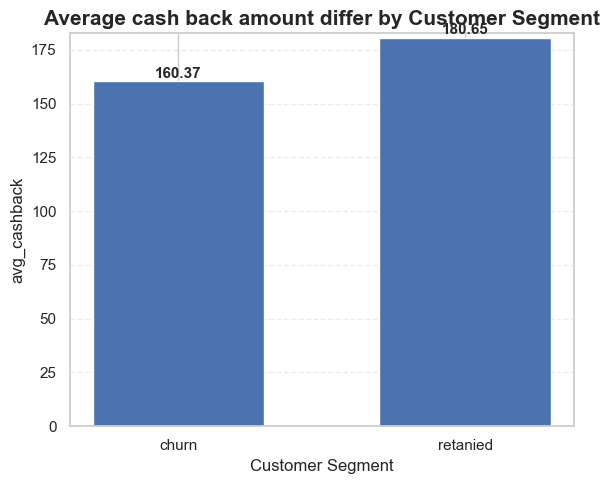

In [78]:
avg_cashback = pd.read_sql_query(text("""select case when churn = 1 then "churn" else "retanied" end as customer_segment , round(avg(cashbackamount),2) as avg_cashback, count(*) as total_customer from clean_dataset group by churn """),engine)
display(avg_cashback)

# Create figure
plt.figure(figsize=(6,5))

# Create bar chart
bars = plt.bar(
    avg_cashback['customer_segment'],
    avg_cashback['avg_cashback'],
    width=0.6
)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Formatting
plt.title('Average cash back amount differ by Customer Segment',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('avg_cashback', fontsize=12)

plt.ylim(0, avg_cashback['avg_cashback'].max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

13 . Which combination of CityTier + PreferredPaymentMode has the highest churn? — surfaces a specific high-risk segment to target.

In [44]:
city_tier_payment_mode_churn = pd.read_sql_query(text(""" with a as (select citytier , payment_mode , sum(churn) as total_churn , count(*) as total_customer , 
round(100.0 * sum(churn) / count(*),2) as churn_rate from clean_dataset group by citytier , payment_mode)
select citytier , payment_mode , total_churn , total_customer , churn_rate , 
dense_rank() over(order by churn_rate desc) as higest_churn_rank from a
;"""),engine)
display(city_tier_payment_mode_churn)

,citytier,payment_mode,total_churn,total_customer,churn_rate,higest_churn_rank
0,2,Cash on Delivery,8.0,16,50.00,1
1,3,Cash on Delivery,40.0,132,30.30,2
2,3,UPI,16.0,58,27.59,3
3,2,UPI,28.0,114,24.56,4
4,3,E wallet,140.0,614,22.80,5
5,1,Cash on Delivery,80.0,366,21.86,6
6,3,Debit Card,116.0,574,20.21,7
7,3,Credit Card,56.0,342,16.37,8
8,2,Credit Card,8.0,50,16.00,9
9,1,Debit Card,236.0,1676,14.08,10


14 . Which customers have high Tenure but low OrderCount ("dormant loyal")? — flags reactivation candidates before they fully churn.

In [45]:
high_tenure_low_order = pd.read_sql_query(text("""with customer_summury as (select customerid , max(tenure_no_of_month_stay) as max_tenure,
max(ordercount) as order_count from clean_dataset group by customerid),
rank_ as (select * , NTILE(4) over(order by  max_tenure desc) as tenure_group ,
 NTILE(4) over(order by  order_count asc) as order_group from customer_summury)
select customerid , max_tenure , order_count from rank_
where tenure_group = 1 and order_count = 1; """),engine)
display(high_tenure_low_order)

,customerid,max_tenure,order_count
0,52720,60.0,1.0
1,50033,30.0,1.0
2,50039,30.0,1.0
3,50184,30.0,1.0
4,50236,30.0,1.0
...,...,...,...
322,50617,15.0,1.0
323,50700,15.0,1.0
324,50715,15.0,1.0
325,50754,15.0,1.0


15 . How does churn rate trend across HourSpendOnApp buckets (low/medium/high engagement)? — checks if app engagement time is protective against churn.

,hour_spent,total_churn,total_customer,churn_rate
0,medium_hour,750.0,4411,17.00
1,low_hour,0.0,38,0.00
2,high_hour,198.0,1179,16.79


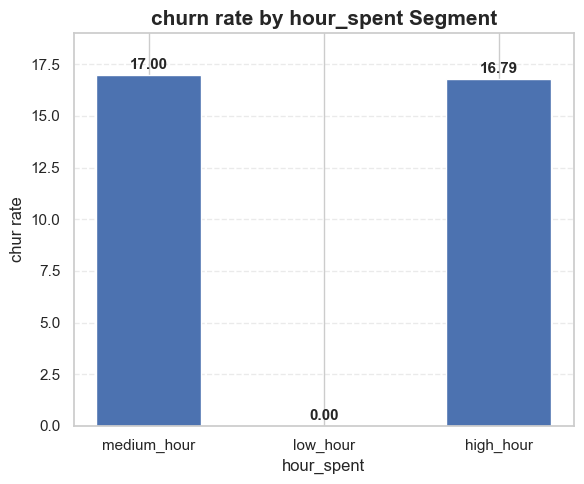

In [79]:
hour_spent_churn_rate = pd.read_sql_query(text("""select case when hour_spend_on_app < 2 then "low_hour"
when hour_spend_on_app < 4 then "medium_hour" 
else "high_hour" end as hour_spent , sum(churn) as total_churn ,
count(*) as total_customer , round(100.0 * sum(churn) / count(*),2) as churn_rate
from clean_dataset group by hour_spent;"""),engine)
display(hour_spent_churn_rate)

# Create figure
plt.figure(figsize=(6,5))

# Create bar chart
bars = plt.bar(
    hour_spent_churn_rate['hour_spent'],
    hour_spent_churn_rate['churn_rate'],
    width=0.6
)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Formatting
plt.title('churn rate by hour_spent Segment',
          fontsize=15,
          fontweight='bold')

plt.xlabel('hour_spent', fontsize=12)
plt.ylabel('chur rate', fontsize=12)

plt.ylim(0, hour_spent_churn_rate['churn_rate'].max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

16 . Rank PreferedOrderCat by a churn-weighted risk score (churn rate × customer count) — prioritizes where retention budget should go first.

In [47]:
category_rank = pd.read_sql_query(text("""WITH category_stats AS (
    SELECT 
        order_cat,
        COUNT(*)                                   AS total_customer,
        SUM(churn)                                 AS total_churn,
        ROUND(100.0 * SUM(churn) / COUNT(*), 2)     AS churn_rate
    FROM clean_dataset
    GROUP BY order_cat
),
overall AS (
    SELECT ROUND(100.0 * SUM(churn) / COUNT(*), 2) AS overall_churn_rate
    FROM clean_dataset
)
SELECT 
    cs.order_cat,
    cs.total_customer,
    cs.total_churn,
    cs.churn_rate,
    o.overall_churn_rate,
    ROUND((cs.churn_rate - o.overall_churn_rate) * cs.total_customer / 100, 2) AS excess_churn_risk_score,
    DENSE_RANK() OVER (
        ORDER BY (cs.churn_rate - o.overall_churn_rate) * cs.total_customer DESC
    ) AS risk_rank
FROM category_stats cs
CROSS JOIN overall o
ORDER BY excess_churn_risk_score DESC; """),engine)
display(category_rank)

,order_cat,total_customer,total_churn,churn_rate,overall_churn_rate,excess_churn_risk_score,risk_rank
0,Mobile Phone,2078,570.0,27.43,16.84,220.06,1
1,Fashion,826,128.0,15.50,16.84,-11.07,2
2,Others,264,20.0,7.58,16.84,-24.45,3
3,Grocery,410,20.0,4.88,16.84,-49.04,4
4,Laptop & Accessory,2050,210.0,10.24,16.84,-135.30,5


17 . Build an RFM-style segmentation using Tenure, OrderCount, and DaySinceLastOrder, then compute churn rate per segment — creates actionable customer tiers for personalized retention offers.

,final_segment,total_customer,total_churn,churn_rate
0,New Customers,784,392.0,50.00
1,Early Churn Risk,22,10.0,45.45
2,Potential Loyalists,75,10.0,13.33
3,Loyal Customers,30,4.0,13.33
4,Other customers,4510,522.0,11.57
5,"At-Risk Loyal,",68,4.0,5.88
6,Lost Customers,139,6.0,4.32


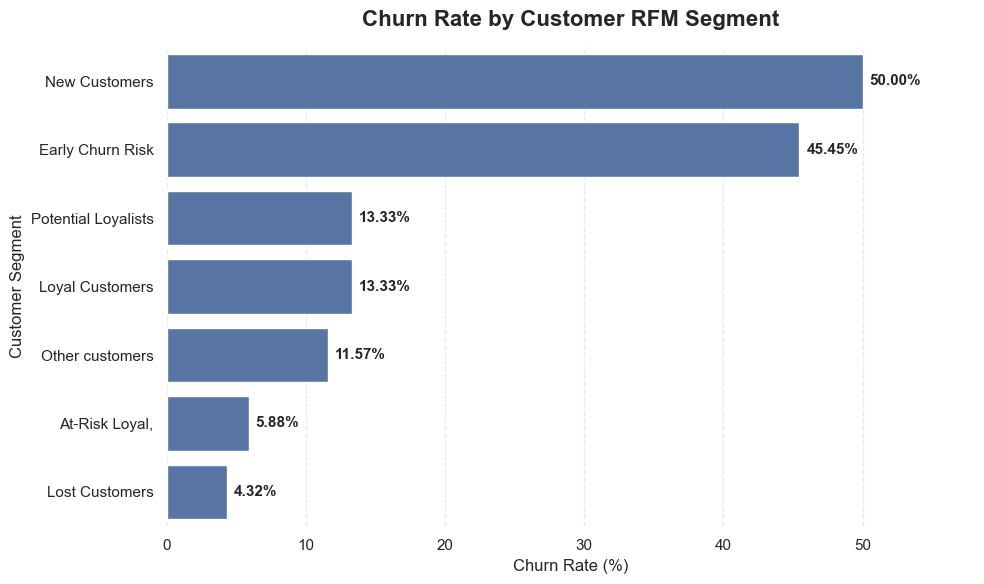

In [85]:
rfm_segment = pd.read_sql_query(text("""with segment as (select CASE WHEN tenure_no_of_month_stay <= 2 THEN 'New' 
WHEN tenure_no_of_month_stay BETWEEN 3 AND 9 THEN 'Growing'
WHEN tenure_no_of_month_stay BETWEEN 10 AND 19 THEN 'Established'
ELSE 'Veteran'END AS tenure_segment,
CASE WHEN ordercount <= 2 THEN 'Low Frequency'
WHEN ordercount BETWEEN 3 AND 5 THEN 'Medium Frequency'
ELSE 'High Frequency' END AS order_count_segment ,
CASE WHEN days_since_last_order <= 3 THEN 'Recent'
WHEN days_since_last_order BETWEEN 4 AND 8 THEN 'Warm'
ELSE 'Inactive' END AS recency_segment  , churn
from clean_dataset)
select case when tenure_segment = 'Veteran'AND order_count_segment = 'High Frequency'AND recency_segment = 'Recent'
THEN 'Loyal Customers' 
when  tenure_segment = 'Veteran'AND order_count_segment = 'High Frequency'AND recency_segment = 'Inactive'
THEN 'At-Risk Loyal,'
when tenure_segment = 'Growing'AND order_count_segment = 'Medium Frequency'AND recency_segment = 'Warm'
THEN 'Potential Loyalists'
when tenure_segment = 'New'AND order_count_segment = 'Low Frequency'AND recency_segment = 'Recent'
THEN 'New Customers'
when tenure_segment = 'New'AND order_count_segment = 'Low Frequency'AND recency_segment = 'Inactive'
THEN 'Early Churn Risk'
when tenure_segment = 'Established'AND order_count_segment = 'Low Frequency'AND recency_segment = 'Inactive'
THEN 'Lost Customers'
else "Other customers" end as final_segment, count(*) as total_customer , 
sum(churn) as total_churn , round(100.0 * sum(churn) / count(*) ,2) as churn_rate 
from segment group by final_segment order by churn_rate desc """),engine)
display(rfm_segment)

# Sort by churn rate (highest to lowest)
rfm_segment = rfm_segment.sort_values('churn_rate', ascending=False)

# Create figure
plt.figure(figsize=(10, 6))

# Horizontal bar chart
ax = sns.barplot(
    data=rfm_segment,
    y='final_segment',
    x='churn_rate'
)

# Add percentage labels
for i, value in enumerate(rfm_segment['churn_rate']):
    ax.text(
        value + 0.5,          # Slightly outside the bar
        i,
        f'{value:.2f}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Formatting
plt.title('Churn Rate by Customer RFM Segment',
          fontsize=16,
          fontweight='bold',
          pad=15)

plt.xlabel('Churn Rate (%)', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)

plt.xlim(0, rfm_segment['churn_rate'].max() + 8)

plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

18 . Which combination of SatisfactionScore, Complain, and DaySinceLastOrder most strongly co-occurs with churn? — pinpoints the top compounding churn drivers for CX/product teams.

In [49]:
combination = pd.read_sql_query(text("""select case when satisfactionscore < 3 then "low satisfy"
when satisfactionscore < 5 then "medium satisfy"
else "high satisfy" end as satisfy_cat , 
case when complain = 1 then "yes"
else "no complain" end as complain_,
case when days_since_last_order between 0 and 3 then "0-3 days"
when days_since_last_order between 4 and 7 then "4-7 days" 
when days_since_last_order between 8 and 10 then "8-10 days"
 when days_since_last_order between 11 and 15 then "11-15 days" 
 else "16+ days" end as recency_segment , count(*) as total_customer , 
sum(churn) as total_churn , count(*) - sum(churn) as retaied_customer ,round(100.0 * sum(churn) / count(*),2) as churn_rate
from clean_dataset group by satisfy_cat , complain_ , recency_segment 
having count(*) >= 100
order by churn_rate desc , total_churn desc  ; """),engine)
display(combination)

,satisfy_cat,complain_,recency_segment,total_customer,total_churn,retaied_customer,churn_rate
0,high satisfy,yes,0-3 days,179,88.0,91.0,49.16
1,medium satisfy,yes,0-3 days,428,182.0,246.0,42.52
2,medium satisfy,yes,8-10 days,117,34.0,83.0,29.06
3,medium satisfy,yes,4-7 days,161,46.0,115.0,28.57
4,low satisfy,yes,0-3 days,315,78.0,237.0,24.76
5,high satisfy,no complain,0-3 days,400,98.0,302.0,24.50
6,low satisfy,yes,4-7 days,116,28.0,88.0,24.14
7,high satisfy,no complain,4-7 days,186,26.0,160.0,13.98
8,medium satisfy,no complain,0-3 days,1139,158.0,981.0,13.87
9,high satisfy,no complain,8-10 days,130,14.0,116.0,10.77


19 . Build a composite engagement score from OrderCount, CouponUsed, and HourSpendOnApp, then correlate it with churn — produces a usable feature for a churn-prediction model.

,engagement_segment,total_customers,churned_customers,churn_rate
0,Low Engagement,2676,470.0,17.56
1,Medium Engagement,2242,368.0,16.41
2,High Engagement,496,75.0,15.12
3,Very High Engagement,214,35.0,16.36


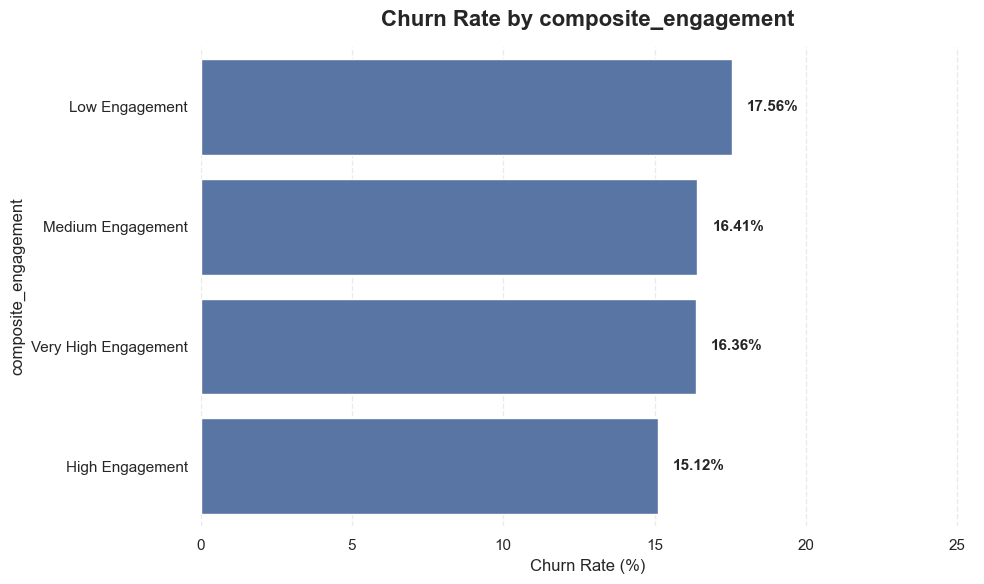

In [87]:
composite_engagement = pd.read_sql_query(text("""WITH engagement AS
(
SELECT *, 
       (ordercount + couponused + hour_spend_on_app) AS engagement_score
FROM clean_dataset
)

SELECT
CASE
    WHEN engagement_score <= 6 THEN 'Low Engagement'
    WHEN engagement_score <= 12 THEN 'Medium Engagement'
    WHEN engagement_score <= 18 THEN 'High Engagement'
    ELSE 'Very High Engagement'
END AS engagement_segment,

COUNT(*) AS total_customers,
SUM(churn) AS churned_customers,
ROUND(100.0 * SUM(churn)/COUNT(*),2) AS churn_rate

FROM engagement
GROUP BY engagement_segment
ORDER BY
CASE engagement_segment
    WHEN 'Low Engagement' THEN 1
    WHEN 'Medium Engagement' THEN 2
    WHEN 'High Engagement' THEN 3
    ELSE 4
END;"""),engine)
display(composite_engagement)

# Sort by churn rate (highest to lowest)
composite_engagement = composite_engagement.sort_values('churn_rate', ascending=False)

# Create figure
plt.figure(figsize=(10, 6))

# Horizontal bar chart
ax = sns.barplot(
    data=composite_engagement,
    y='engagement_segment',
    x='churn_rate'
)

# Add percentage labels
for i, value in enumerate(composite_engagement['churn_rate']):
    ax.text(
        value + 0.5,          # Slightly outside the bar
        i,
        f'{value:.2f}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Formatting
plt.title('Churn Rate by composite_engagement',
          fontsize=16,
          fontweight='bold',
          pad=15)

plt.xlabel('Churn Rate (%)', fontsize=12)
plt.ylabel('composite_engagement', fontsize=12)

plt.xlim(0, composite_engagement['churn_rate'].max() + 8)

plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

20 . Identify "high-value at-risk" customers: high historical CashbackAmount/OrderCount but recent inactivity — creates a priority outreach list for the retention team.

In [51]:
high_value_risk = pd.read_sql_query(text("""WITH customer_value AS
(
SELECT
    customerid,
    SUM(ordercount) AS total_orders,
    SUM(cashbackamount) AS total_cashback,
    MAX(days_since_last_order) AS days_since_last_order
FROM clean_dataset
GROUP BY customerid
),

ranked AS
(
SELECT *,
       NTILE(4) OVER(ORDER BY total_cashback DESC) AS cashback_quartile,
       NTILE(4) OVER(ORDER BY total_orders DESC) AS order_quartile
FROM customer_value
)

SELECT
    customerid,
    total_orders,
    total_cashback,
    days_since_last_order
FROM ranked
WHERE cashback_quartile = 1
  AND order_quartile = 1
  AND days_since_last_order >= 30
ORDER BY total_cashback DESC, total_orders DESC; """),engine)
display(high_value_risk)

,customerid,total_orders,total_cashback,days_since_last_order
0,52041,11.0,206.0,46.0


21 . Does a bigger OrderAmountHikeFromlastYear (price increase) correlate with higher churn? — tests price sensitivity as a churn driver.

,hike_group,total_customers,churned_customers,churn_rate
0,11-13(low),1860,354.0,19.03
1,14-16(medium),1888,276.0,14.62
2,17-20 (high),1172,184.0,15.70
3,very high(20 +),708,134.0,18.93


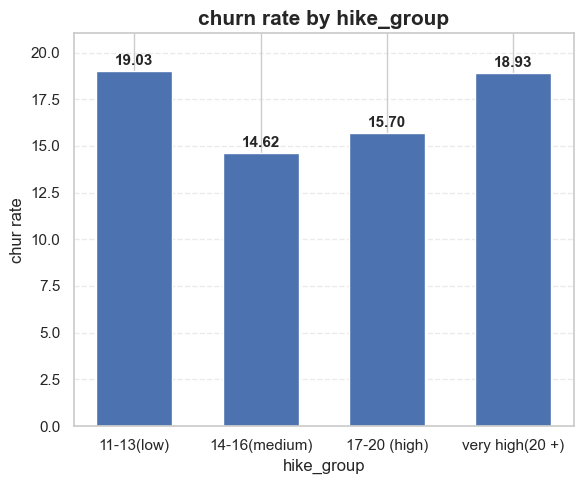

In [88]:
price_increase = pd.read_sql_query(text("""SELECT
    case when order_amount_hike_from_last_year <= 13 then "11-13(low)"
    when order_amount_hike_from_last_year <= 16 then "14-16(medium)"
     when order_amount_hike_from_last_year <= 20 then "17-20 (high)"
    else "very high(20 +)" end as hike_group,
    COUNT(*) AS total_customers,
    SUM(churn) AS churned_customers,
    ROUND(100.0 * SUM(churn) / COUNT(*), 2) AS churn_rate
FROM clean_dataset
GROUP BY hike_group
ORDER BY hike_group; """),engine)
display(price_increase)


# Create figure
plt.figure(figsize=(6,5))

# Create bar chart
bars = plt.bar(
    price_increase['hike_group'],
    price_increase['churn_rate'],
    width=0.6
)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Formatting
plt.title('churn rate by hike_group',
          fontsize=15,
          fontweight='bold')

plt.xlabel('hike_group', fontsize=12)
plt.ylabel('chur rate', fontsize=12)

plt.ylim(0, price_increase['churn_rate'].max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

22 . Bucket customers into tenure cohorts (0–6mo, 6–12mo, 1–2yr, 2yr+) and compute churn rate + avg SatisfactionScore per cohort — shows exactly where in the customer lifecycle churn spikes, guiding onboarding vs. loyalty program investment.

In [ ]:
tenure_churn = pd.read_sql_query(text("""select case when tenure_no_of_month_stay <=6 then "0-6 month"
when tenure_no_of_month_stay <= 12 then "6-12 month"
when tenure_no_of_month_stay <= 24 then "1-2 year"
else "2+ year"  end as tenure_bucket , count(*) as total_customer , sum(churn) as total_churn , round(100.0 * sum(churn) / count(*),2) as churn_rate , round(avg(satisfactionscore),2) as avg_satisfaction from clean_dataset group by tenure_bucket"""),engine)
display(tenure_churn)

# Style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --------------------------
# Bar Chart 1 : Total Churn Customers
# --------------------------
ax1 = sns.barplot(
    data=tenure_churn,
    x='tenure_bucket',
    y='total_churn',
    hue='citytier',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

# Add data labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

axes[0].set_title(
    'Total Churn Customers by tenure_bucket',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('tenure_bucket', fontsize=12)
axes[0].set_ylabel('Total Churn Customers', fontsize=12)

# --------------------------
# Bar Chart 2 : Churn Rate
# --------------------------
ax2 = sns.barplot(
    data=tenure_churn,
    x='tenure_bucket',
    y='churn_rate',
    hue='citytier',
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)

# Add percentage labels
for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt='%.2f%%',
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_title(
    'Churn Rate by City Tier',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('City Tier', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)

# Set y-limit for better spacing
axes[1].set_ylim(0, city_tier_rate['churn_rate'].max() + 5)

plt.tight_layout()
plt.show()

,tenure_bucket,total_customer,total_churn,churn_rate,avg_satisfaction
0,0-6 month,2150,697.0,32.42,3.11
1,6-12 month,1584,156.0,9.85,2.99
2,1-2 year,1467,95.0,6.48,3.09
3,2+ year,427,0.0,0.00,3.06


23 . Using a window function, rank customers within each PreferedOrderCat by CashbackAmount and flag the bottom-tenure/top-spend group as VIP-at-risk — identifies customers worth a retention call before they churn.

In [54]:
vip_at_risk = pd.read_sql_query(text("""WITH ranked AS (
    SELECT 
        customerid,
        order_cat,
        cashbackamount,
        tenure_no_of_month_stay AS tenure,
        churn,
        ROW_NUMBER() OVER (
            PARTITION BY order_cat 
            ORDER BY cashbackamount DESC
        ) AS cashback_rank,
        
        ROW_NUMBER() OVER (
            PARTITION BY order_cat 
            ORDER BY tenure_no_of_month_stay ASC
        ) AS tenure_rank
        
    FROM clean_dataset
)

SELECT 
    customerid,
    order_cat,
    cashbackamount,
    tenure,
    cashback_rank,
    tenure_rank,
    churn,
    CASE 
        WHEN cashback_rank <= 50 
         AND tenure_rank <= 100  
        THEN 'VIP-at-risk'
        ELSE 'Normal'
    END AS vip_flag
    
FROM ranked
WHERE cashback_rank <= 50             
ORDER BY order_cat, cashback_rank; """),engine)
display(vip_at_risk)

,customerid,order_cat,cashbackamount,tenure,cashback_rank,tenure_rank,churn,vip_flag
0,55201,Fashion,263,14.0,1,540,0,Normal
1,53731,Fashion,263,14.0,2,551,0,Normal
2,54123,Fashion,262,11.0,3,395,0,Normal
3,54239,Fashion,262,11.0,4,396,0,Normal
4,52936,Fashion,262,5.0,5,174,0,Normal
...,...,...,...,...,...,...,...,...
245,52826,Others,320,5.0,46,5,1,VIP-at-risk
246,54394,Others,320,24.0,47,195,0,Normal
247,54128,Others,319,13.0,48,30,0,VIP-at-risk
248,52948,Others,319,14.0,49,39,0,VIP-at-risk
